In [1]:
import clickhouse_connect
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Connect to ClickHouse ---
client = clickhouse_connect.get_client(
    host='192.168.88.253',  # change as needed
    port=8123,
    username='default',  # or your username
    password='uf80Zfvt7XWORQtn',     
)


In [36]:

query = """
SELECT
    toTimezone(dt, 'Europe/Moscow') AS dt,
    container,
    event,
    data.visible_cell
FROM raw.rl_snake_logs
PREWHERE (deploy_dt = (
    SELECT max(deploy_dt)
    FROM raw.rl_snake_logs
)) AND match(container, 'inf') AND match(event, 'state_received')
ORDER BY dt DESC
limit 100

"""

df = client.query_df(query)


df

,dt,container,event,data.visible_cell
0,2025-09-06 13:28:30.131853+03:00,inference,state_received,None
1,2025-09-06 13:28:30.120780+03:00,inference,state_received,None
2,2025-09-06 13:28:30.109793+03:00,inference,state_received,None
3,2025-09-06 13:28:30.098836+03:00,inference,state_received,None
4,2025-09-06 13:28:30.087881+03:00,inference,state_received,None
...,...,...,...,...
95,2025-09-06 13:28:29.055382+03:00,inference,state_received,None
96,2025-09-06 13:28:29.045124+03:00,inference,state_received,None
97,2025-09-06 13:28:29.035014+03:00,inference,state_received,None
98,2025-09-06 13:28:29.024598+03:00,inference,state_received,None


dt           datetime64[ns, Europe/Moscow]
container                   string[python]
event                       string[python]
data                                object
dtype: object

In [24]:
df[df['data'].str.contains('episode')]

KeyError: "None of [Index([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,\n       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,\n       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,\n       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,\n       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,\n       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,\n       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,\n       nan, nan],\n      dtype='float64')] are in the [columns]"

In [30]:
states = df['data'].to_list()

In [31]:
states[5]4

{'delay_s': '0.00046753883361816406',
 'episode': np.int64(558),
 'frame': np.int64(2034),
 'function': 'neural_agent_local',
 'game_over': np.False_,
 'line': np.int64(176),
 'logger_name': 'root',
 'module': 'main',
 'reward': np.float64(0.1),
 'visible_cells': {'0,5': 'EMPTY',
  '1,4': 'EMPTY',
  '1,5': 'EMPTY',
  '1,6': 'EMPTY',
  '10,5': 'EMPTY',
  '2,3': 'EMPTY',
  '2,4': 'EMPTY',
  '2,5': 'EMPTY',
  '2,6': 'EMPTY',
  '2,7': 'EMPTY',
  '3,2': 'EMPTY',
  '3,3': 'EMPTY',
  '3,4': 'EMPTY',
  '3,5': 'EMPTY',
  '3,6': 'EMPTY',
  '3,7': 'EMPTY',
  '3,8': 'EMPTY',
  '4,1': 'EMPTY',
  '4,2': 'EMPTY',
  '4,3': 'EMPTY',
  '4,4': 'EMPTY',
  '4,5': 'EMPTY',
  '4,6': 'EMPTY',
  '4,7': 'EMPTY',
  '4,8': 'EMPTY',
  '4,9': 'EMPTY',
  '5,0': 'BODY',
  '5,1': 'EMPTY',
  '5,10': 'BODY',
  '5,2': 'EMPTY',
  '5,3': 'EMPTY',
  '5,4': 'EMPTY',
  '5,5': 'HEAD',
  '5,6': 'BODY',
  '5,7': 'BODY',
  '5,8': 'BODY',
  '5,9': 'BODY',
  '6,1': 'EMPTY',
  '6,2': 'EMPTY',
  '6,3': 'EMPTY',
  '6,4': 'EMPTY',
  '6

In [41]:
%run ../docs/state_visualizer.py

# From list of states (your log storage)
#states = [{'visible_cells': {...}, 'reward': 0.1, 'episode': 1, 'frame': 42}, ...]
#visualizer = SnakeStateVisualizer(states[:1000])
#anim = visualizer.animate()

# From JSON file
#visualizer = SnakeStateVisualizer.from_file('experiment_states.json')
#anim = visualizer.animate()

# Or use convenience functions
#anim = visualize_states(states, interval=200)
#anim = visualize_from_file('states.json', interval=200)

Usage: python state_visualizer.py <states_file.json> [interval_ms]


SystemExit: 1

In [43]:
visualizer = SnakeStateVisualizer(states)



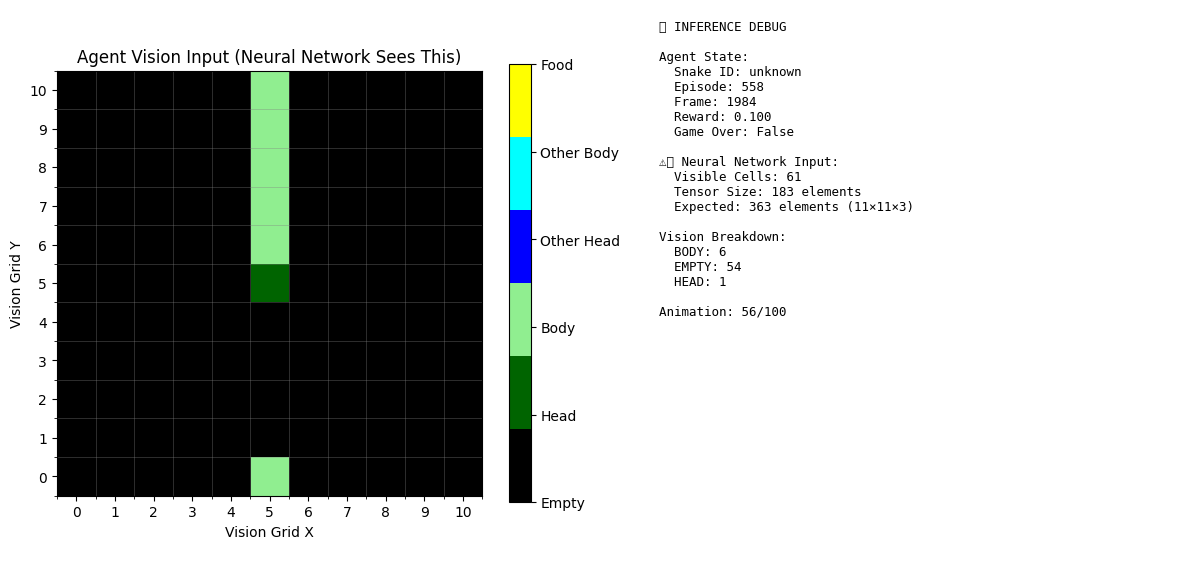

In [44]:
visualizer.show_frame(55)